In [1]:
# General imports 
import os 
import numpy as np
import pandas as pd
from pathlib import Path
import scipy.stats as stats 
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# PyNWB imports
from hdmf_zarr import NWBZarrIO

# # Util imports 
from utils.filter_roi_table import filter_roi_table, filter_dff

In [2]:
metadata = pd.read_csv(os.path.join('/data/', 'metadata', 'bci_metadata.csv'))
metadata.head()

,project_name,session_type,_id,name,subject_id,genotype,virus,date_of_birth,sex,modality,session_date,age,session_time,targeted_structure,ophys_fov,session_number
0,Brain Computer Interface,BCI single neuron stim,b8827d25-495f-46a8-9f33-ffb24da527a5,single-plane-ophys_731015_2025-01-10_18-06-31_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-10,302,16:46:51.981999,Primary Motor Cortex,FOV_04,18.0
1,Brain Computer Interface,BCI single neuron stim,127a3e78-729c-4df7-bf34-1b9308939587,single-plane-ophys_731015_2025-01-24_20-00-44_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-24,316,18:41:22.550000,Primary Motor Cortex,FOV_04,20.0
2,Brain Computer Interface,BCI single neuron stim,0162d41c-613c-4215-b0aa-9690f85a9fda,single-plane-ophys_731015_2025-01-28_18-56-35_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-28,320,17:40:57.996000,Primary Motor Cortex,FOV_04,22.0
3,Brain Computer Interface,BCI single neuron stim,b9a4c361-66b0-4cd5-9392-75d116ef3385,single-plane-ophys_731015_2025-01-31_20-37-19_...,731015,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-03-14,Female,Planar optical physiology,2025-01-31,323,20:37:19.623000,Primary Motor Cortex,FOV_04,23.0
4,Brain Computer Interface,BCI single neuron stim,30006aee-36db-44d9-a1fb-1b6583619434,single-plane-ophys_740369_2025-01-09_17-18-37_...,740369,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,2024-05-03,Female,Planar optical physiology,2025-01-09,251,16:01:04.455000,Primary Motor Cortex,FOV_05,22.0


In [3]:
# Select a mouse 
subject_id = 754303

# Look at its metadata, sorted by 'session_number'
this_mouse_metadata = metadata[metadata['subject_id']==subject_id].sort_values(by='session_number')

# Select a session for this mouse 
session_name = this_mouse_metadata.name.values[0]

# Get the directory to THAT session's NWB file
session_dir = os.path.join('/data/', 'brain-computer-interface-v2', session_name)

# Now find the NWB file and set the path to load it
nwb_file = [file for file in os.listdir(session_dir) if 'nwb' in file][0]
nwb_path = os.path.join(session_dir, nwb_file)

with NWBZarrIO(str(nwb_path), 'r') as io:
    nwbfile = io.read()

/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


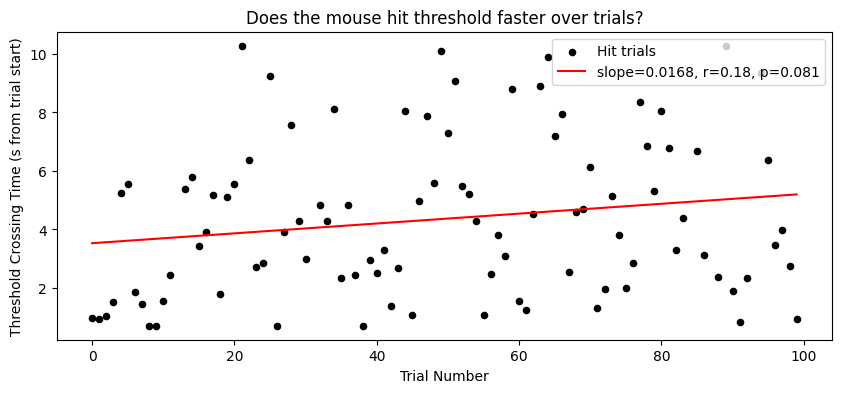

Slope: 0.0168
R: 0.18, p-value: 0.081


In [4]:
# Get threshold crossing time relative to trial start (how fast did they hit threshold?)

trials = nwbfile.stimulus["Trials"].to_dataframe()

crossing_times = []

for index, row in trials.iterrows():
    tct = row.threshold_crossing_times
    if np.isscalar(tct):
        crossing_times.append(tct if np.isfinite(tct) else np.nan)
    else:
        valid = tct[np.isfinite(tct)]
        crossing_times.append(valid[0] if len(valid) > 0 else np.nan)

crossing_times = np.array(crossing_times)
trial_numbers = np.arange(len(trials))

# Only use hit trials (non-nan)
hit_mask = np.isfinite(crossing_times)
x = trial_numbers[hit_mask]
y = crossing_times[hit_mask]

# Linear regression
slope, intercept, r, p, _ = stats.linregress(x, y)

# Plot
plt.figure(figsize=(10, 4))
plt.scatter(x, y, color='black', s=20, label='Hit trials')
plt.plot(x, slope * x + intercept, color='red', label=f'slope={slope:.4f}, r={r:.2f}, p={p:.3f}')
plt.xlabel('Trial Number')
plt.ylabel('Threshold Crossing Time (s from trial start)')
plt.title('Does the mouse hit threshold faster over trials?')
plt.legend()
plt.show()

print(f"Slope: {slope:.4f}")
print(f"R: {r:.2f}, p-value: {p:.3f}")

In [5]:
zaber_step_times = []

#for each trial, add the event times to trial start and append to appropriate list
for index, row in trials.iterrows():
    tct = row.threshold_crossing_times
    
    if np.isscalar(tct):
        if np.isfinite(tct):
            print(f"Trial {index}: threshold crossed at {tct:.2f} s relative to trial start")
        else:
            print(f"Trial {index}: miss (no threshold crossing)")
    else:
        valid = tct[np.isfinite(tct)]
        print(f"Trial {index}: threshold crossed at {valid} s relative to trial start")

#reshape zaber_step_times (this is needed because there is a list of times for each trial)
zaber_step_times = np.hstack(zaber_step_times)

zaber_step_times

Trial 0: threshold crossed at 0.97 s relative to trial start
Trial 1: threshold crossed at 0.94 s relative to trial start
Trial 2: threshold crossed at 1.06 s relative to trial start
Trial 3: threshold crossed at 1.50 s relative to trial start
Trial 4: threshold crossed at 5.25 s relative to trial start
Trial 5: threshold crossed at 5.56 s relative to trial start
Trial 6: threshold crossed at 1.86 s relative to trial start
Trial 7: threshold crossed at 1.46 s relative to trial start
Trial 8: threshold crossed at 0.71 s relative to trial start
Trial 9: threshold crossed at 0.71 s relative to trial start
Trial 10: threshold crossed at 1.54 s relative to trial start
Trial 11: threshold crossed at 2.44 s relative to trial start
Trial 12: miss (no threshold crossing)
Trial 13: threshold crossed at 5.38 s relative to trial start
Trial 14: threshold crossed at 5.79 s relative to trial start
Trial 15: threshold crossed at 3.43 s relative to trial start
Trial 16: threshold crossed at 3.92 s rel

ValueError: need at least one array to concatenate

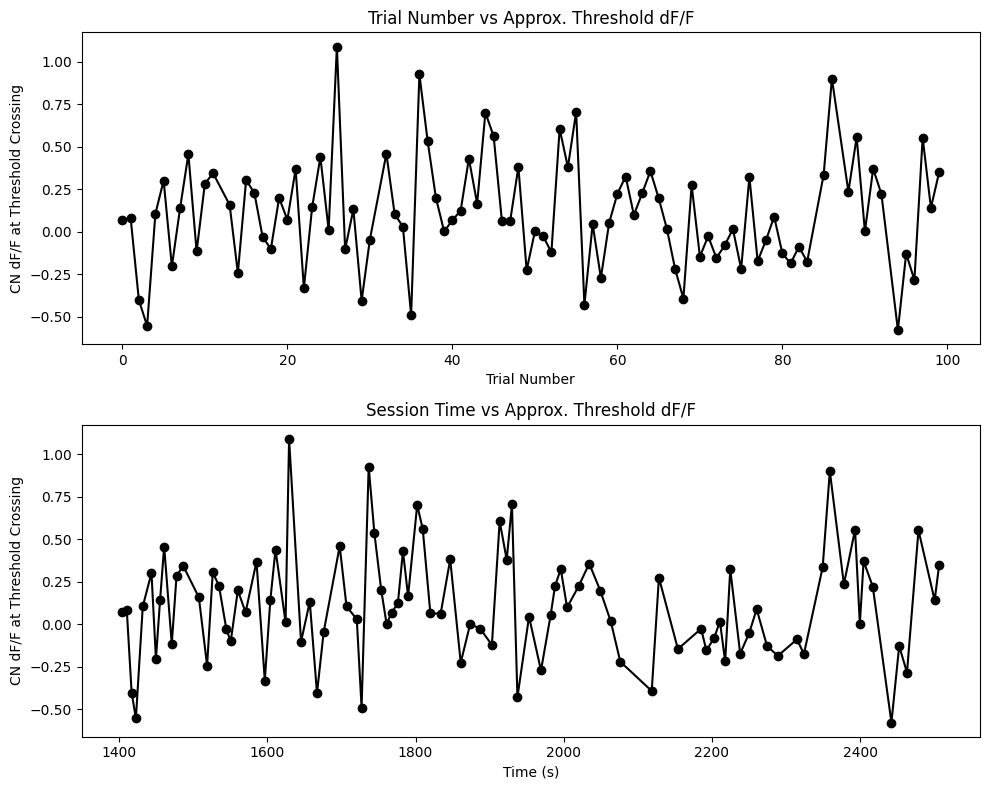

In [6]:
dff = nwbfile.processing["processed"].data_interfaces["dff"].roi_response_series["dff"].data
frame_rate = nwbfile.imaging_planes["processed"].imaging_rate
cn_index = trials.closest_roi.unique()[0]

threshold_per_trial = []

for index, row in trials.iterrows():
    tct = row.threshold_crossing_times
    
    if np.isscalar(tct) and np.isfinite(tct):
        abs_time = tct + row.start_time
        frame = int(abs_time * frame_rate)
        dff_at_crossing = dff[frame, cn_index]
        threshold_per_trial.append({
            'trial': index,
            'abs_time': abs_time,
            'dff_at_threshold': dff_at_crossing
        })

df_threshold = pd.DataFrame(threshold_per_trial)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Trial number vs dff
axes[0].plot(df_threshold['trial'], df_threshold['dff_at_threshold'], 'o-', color='black')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('CN dF/F at Threshold Crossing')
axes[0].set_title('Trial Number vs Approx. Threshold dF/F')

# Time vs dff
axes[1].plot(df_threshold['abs_time'], df_threshold['dff_at_threshold'], 'o-', color='black')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('CN dF/F at Threshold Crossing')
axes[1].set_title('Session Time vs Approx. Threshold dF/F')

plt.tight_layout()
plt.show()

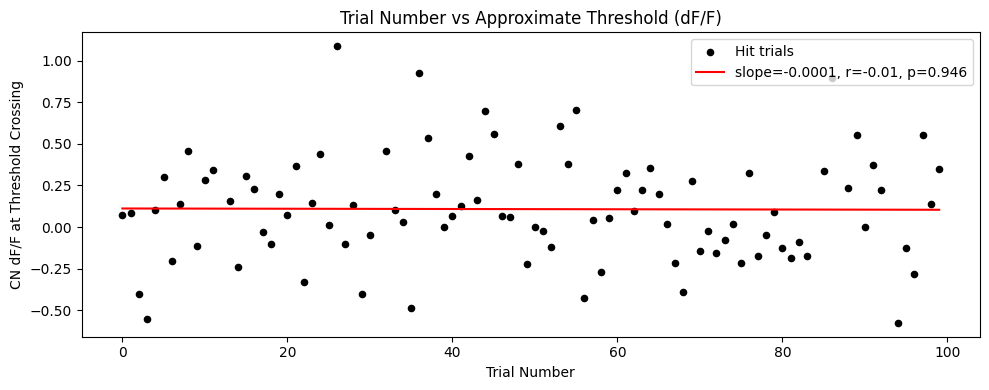

Slope: -0.0001
R: -0.01, p-value: 0.946


In [7]:
from scipy.stats import linregress

x = df_threshold['trial'].values
y = df_threshold['dff_at_threshold'].values

slope, intercept, r, p, _ = linregress(x, y)

plt.figure(figsize=(10, 4))
plt.scatter(x, y, color='black', s=20, label='Hit trials')
plt.plot(x, slope * x + intercept, color='red', label=f'slope={slope:.4f}, r={r:.2f}, p={p:.3f}')
plt.xlabel('Trial Number')
plt.ylabel('CN dF/F at Threshold Crossing')
plt.title('Trial Number vs Approximate Threshold (dF/F)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {slope:.4f}")
print(f"R: {r:.2f}, p-value: {p:.3f}")

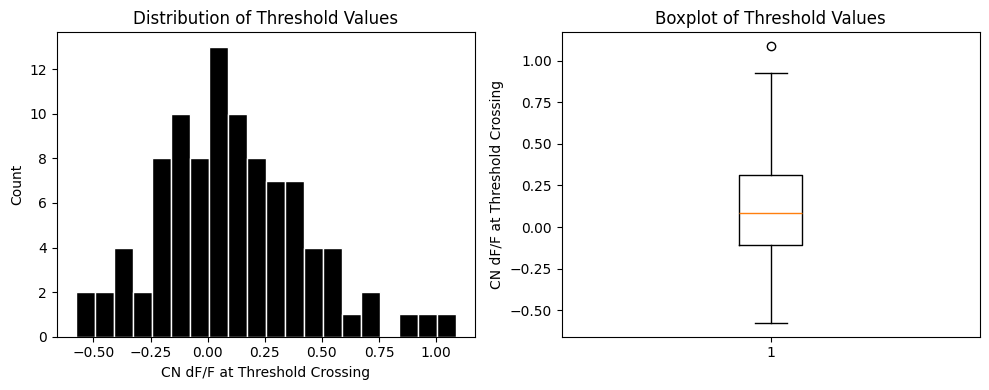

Mean: 0.108
Std: 0.319
Min: -0.577
Max: 1.088


In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_threshold['dff_at_threshold'], bins=20, color='black', edgecolor='white')
plt.xlabel('CN dF/F at Threshold Crossing')
plt.ylabel('Count')
plt.title('Distribution of Threshold Values')

plt.subplot(1, 2, 2)
plt.boxplot(df_threshold['dff_at_threshold'])
plt.ylabel('CN dF/F at Threshold Crossing')
plt.title('Boxplot of Threshold Values')

plt.tight_layout()
plt.show()

print(f"Mean: {df_threshold['dff_at_threshold'].mean():.3f}")
print(f"Std: {df_threshold['dff_at_threshold'].std():.3f}")
print(f"Min: {df_threshold['dff_at_threshold'].min():.3f}")
print(f"Max: {df_threshold['dff_at_threshold'].max():.3f}")

In [11]:
# First check epoch table to understand photostim epoch structure
# Run this for one session to see what's available

this_mouse_metadata = metadata[metadata['subject_id'] == 754303].sort_values(by='session_number')
session_name = this_mouse_metadata.name.values[0]  # S2
session_dir = os.path.join('/data/', 'brain-computer-interface-v2', session_name)
nwb_file = [f for f in os.listdir(session_dir) if 'nwb' in f][0]
nwb_path = os.path.join(session_dir, nwb_file)

with NWBZarrIO(str(nwb_path), 'r') as io:
    nwbfile = io.read()

epoch_table = nwbfile.intervals["epochs"].to_dataframe()
print(epoch_table[['stimulus_name', 'start_time', 'stop_time', 'start_frame', 'stop_frame']])

photostim = nwbfile.stimulus["PhotostimTrials"].to_dataframe()
print(photostim['stimulus_name'].unique())
print(photostim.head())

/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


     stimulus_name   start_time    stop_time  start_frame  stop_frame
id                                                                   
0        photostim     0.000000  1190.816190            0       69381
1            spont  1190.833353  1403.333825        69382       81763
2              BCI  1403.350989  2531.537809        81764      147496
3       spont_post  2531.554973  3050.577206       147497      177737
4   photostim_post  3050.594370  4323.177158       177738      251883
['photostim' 'photostim_post']
    start_time  stop_time  start_frame  stop_frame            tiff_file  \
id                                                                        
0     0.000000   1.115623            0          65  spont_slm_00001.tif   
1     1.132787   2.334227           66         136  spont_slm_00002.tif   
2     2.351390   3.467014          137         202  spont_slm_00003.tif   
3     3.484177   4.565473          203         266  spont_slm_00004.tif   
4     4.582637   5.681097    

In [21]:
def get_connectivity(subject_id, prev_session_num, curr_session_num, time_ext=2):
    """
    Measure connectivity from prev CN → curr CN
    in both pre and post BCI photostim epochs of the PREVIOUS session
    """
    this_mouse_metadata = metadata[metadata['subject_id'] == subject_id].sort_values(by='session_number')
    
    # Load PREVIOUS session (this is where we measure connectivity)
    prev_session_name = this_mouse_metadata[this_mouse_metadata['session_number'] == prev_session_num]['name'].values[0]
    prev_session_dir = os.path.join('/data/', 'brain-computer-interface-v2', prev_session_name)
    prev_nwb_file = [f for f in os.listdir(prev_session_dir) if 'nwb' in f][0]
    with NWBZarrIO(os.path.join(prev_session_dir, prev_nwb_file), 'r') as io:
        prev_nwbfile = io.read()

    prev_cn = prev_nwbfile.stimulus["Trials"].to_dataframe().closest_roi.unique()[0]
    prev_dff = prev_nwbfile.processing["processed"].data_interfaces["dff"].roi_response_series["dff"].data
    prev_frame_rate = prev_nwbfile.imaging_planes["processed"].imaging_rate
    prev_photostim = prev_nwbfile.stimulus["PhotostimTrials"].to_dataframe()
    prev_epochs = prev_nwbfile.intervals["epochs"].to_dataframe()
    print(f"Subject {subject_id} | S{prev_session_num} CN index: {prev_cn}")

    # Load CURRENT session to get its CN index
    curr_session_name = this_mouse_metadata[this_mouse_metadata['session_number'] == curr_session_num]['name'].values[0]
    curr_session_dir = os.path.join('/data/', 'brain-computer-interface-v2', curr_session_name)
    curr_nwb_file = [f for f in os.listdir(curr_session_dir) if 'nwb' in f][0]
    with NWBZarrIO(os.path.join(curr_session_dir, curr_nwb_file), 'r') as io:
        curr_nwbfile = io.read()

    curr_cn = curr_nwbfile.stimulus["Trials"].to_dataframe().closest_roi.unique()[0]
    print(f"Subject {subject_id} | S{curr_session_num} CN index: {curr_cn}")

    # Get pre and post epoch frame boundaries
    pre_epoch  = prev_epochs[prev_epochs['stimulus_name'] == 'photostim'].iloc[0]
    post_epoch = prev_epochs[prev_epochs['stimulus_name'] == 'photostim_post'].iloc[0]

    def measure_response(photostim_trials, epoch, target_cn):
        # Filter trials to this epoch only
        trials_in_epoch = photostim_trials[
            (photostim_trials['start_frame'] >= epoch['start_frame']) &
            (photostim_trials['stop_frame']  <= epoch['stop_frame']) &
            (photostim_trials['closest_roi'] == target_cn)
        ]
        print(f"  Found {len(trials_in_epoch)} trials for CN {target_cn} in epoch")
        
        responses = []
        for _, row in trials_in_epoch.iterrows():
            post_start = int(row.stop_frame)
            post_end   = int(post_start + time_ext * prev_frame_rate)
            response   = np.nanmean(prev_dff[post_start:post_end, curr_cn])
            responses.append(response)
        return np.mean(responses) if responses else np.nan

    print(f"  Measuring pre-BCI connectivity (S{prev_session_num} CN → S{curr_session_num} CN):")
    pre_conn  = measure_response(prev_photostim, pre_epoch,  prev_cn)
    print(f"  Measuring post-BCI connectivity (S{prev_session_num} CN → S{curr_session_num} CN):")
    post_conn = measure_response(prev_photostim, post_epoch, prev_cn)

    return {'subject': subject_id, 
            'prev_session': prev_session_num, 
            'curr_session': curr_session_num,
            'pre_BCI': pre_conn, 
            'post_BCI': post_conn}

# Run for all three pairs
pairs = [
    (731015, 18, 22),
    (754303,  2,  3),
    (740369, 22, 24),
]

results = []
for subject_id, prev_snum, curr_snum in pairs:
    r = get_connectivity(subject_id, prev_snum, curr_snum)
    results.append(r)

df_results = pd.DataFrame(results)
print(df_results)

/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Subject 731015 | S18 CN index: 38


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Subject 731015 | S22 CN index: 26
  Measuring pre-BCI connectivity (S18 CN → S22 CN):
  Found 16 trials for CN 38 in epoch
  Measuring post-BCI connectivity (S18 CN → S22 CN):
  Found 43 trials for CN 38 in epoch


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


...

Subject 754303 | S3 CN index: 26
  Measuring pre-BCI connectivity (S2 CN → S3 CN):
  Found 0 trials for CN 19 in epoch
  Measuring post-BCI connectivity (S2 CN → S3 CN):
  Found 0 trials for CN 19 in epoch


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Subject 740369 | S22 CN index: 20


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Subject 740369 | S24 CN index: 135
  Measuring pre-BCI connectivity (S22 CN → S24 CN):
  Found 21 trials for CN 20 in epoch
  Measuring post-BCI connectivity (S22 CN → S24 CN):
  Found 15 trials for CN 20 in epoch
   subject  prev_session  curr_session   pre_BCI  post_BCI
0   731015            18            22  0.464428  0.291082
1   754303             2             3       NaN       NaN
2   740369            22            24  0.157919  0.203502


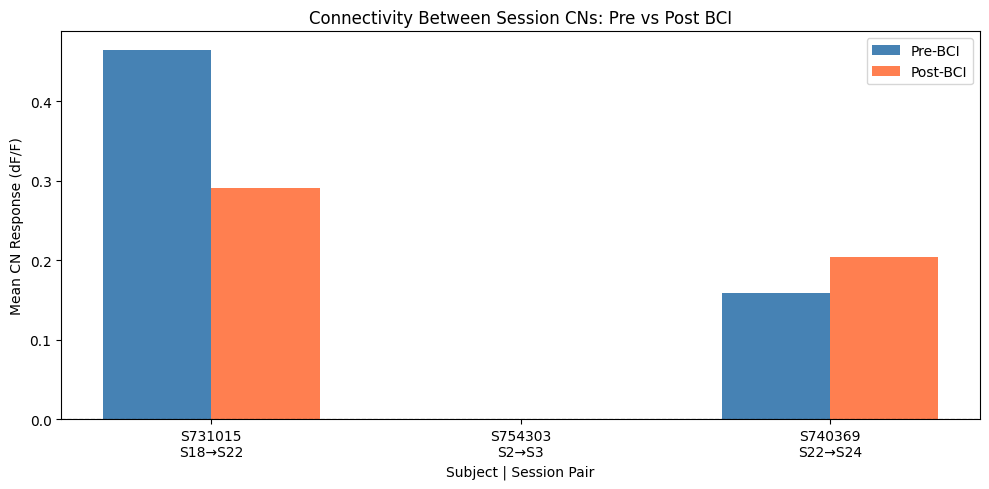

In [23]:
# Plot: paired bar chart, pre vs post for each subject/session pair
labels = [f"S{r['subject']}\nS{r['prev_session']}→S{r['curr_session']}" for r in results]
x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_pre  = ax.bar(x - width/2, df_results['pre_BCI'],  width, label='Pre-BCI',  color='steelblue')
bars_post = ax.bar(x + width/2, df_results['post_BCI'], width, label='Post-BCI', color='coral')

ax.set_xlabel('Subject | Session Pair')
ax.set_ylabel('Mean CN Response (dF/F)')
ax.set_title('Connectivity Between Session CNs: Pre vs Post BCI')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()